In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag


In [19]:
#setting constants and variable values
h = 6.626e-34
m = 9.1e-28
h_bar = h/(2*np.pi)

(np.float64(-6.027982474893858e-20),
 array([3.14248467e-45, 1.25747463e-44, 2.83122078e-44, ...,
        2.83132598e-44, 1.25752832e-44, 3.14267977e-45]))

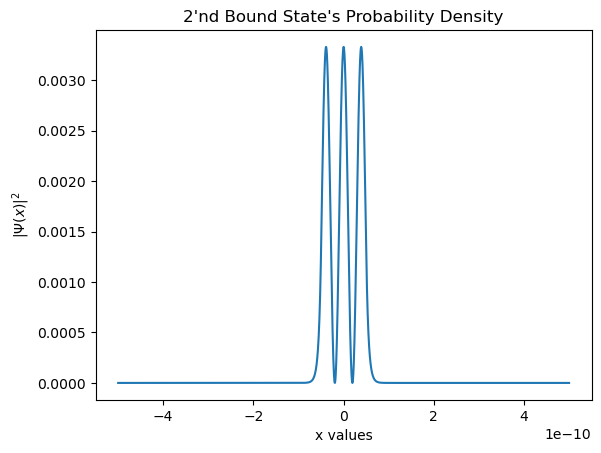

In [27]:
def finite_well(V_0,a,N,n):

    """
    Solves the time independent schrodinger equation for the bound states of a finite well system

    Inputs:
    V_0(float) - Depth of the finite well
    a(float) - width of the well
    N(int) - number of internal points in spatial grid(excluding the first and last points)
    n(int) - n'th bound state

    Output:
    Plots the n'th bound states probability density

    Return:
    Energies(float) - n'th bound state's energy
    Probabilty density - corresponding probabiltiy density
    """
    
   #create tridiagonal kinetic matrix along -L to L
    L = 5*a
    dx = (2*L)/(N+1)
    x_values = np.linspace(-L+dx,L-dx,N)
    coef = h_bar**2 * 1/(2*m*dx**2)
    T = coef * (np.diag(np.full(N,2)) - np.diag(np.ones(N-1),1) - np.diag(np.ones(N-1),-1))

    #creating potential matrix
    V_values = []
    for i in x_values:
        if -a/2<=i<=a/2:
            V_values.append(-V_0)
        else:
            V_values.append(0)
    V = np.diag(V_values)

    H =(T+V)

    #solving for eigenvalues and eigenvectors
    energies, wavefunctions = np.linalg.eigh(H)

    #eliminating any energies that are not considered bound states
    bound_mask = (energies<=0) & (energies>-V_0)
    energies = energies[bound_mask]
    wavefunctions = wavefunctions[:,bound_mask]

    prob_density = np.abs(wavefunctions)**2

    if n==1 :
        suffix = "'st"
    elif n==2:
        suffix = "'nd"
    elif n==3:
        suffix = "'rd"
    else:
        suffix = "'th"
        
    plt.figure()
    plt.title(f"{n}{suffix} Bound State's Probability Density")
    plt.xlabel("x values")
    plt.ylabel(r"$|\Psi(x)|^2$")
    plt.plot(x_values,prob_density[:,n])

    return energies[n], prob_density[:,n]

finite_well(1e-19,0.1e-9,5000,2)  
